# Pytorch and Classification Test
Finally some real Neural Networks

## Section 1: Dataset and Dataloaders (5 min)
In this section you will implement a torchvision Dataset and Dataload for the MNIST dataset

In [1]:
import numpy as np     # <----- Our old friend

import torch            # |  Our new best friends -- this is the main pytroch library
import torch.nn as nn   # |  This is just shortening the name of this module since we're gonna use it a lot -- this is the one that has neural network objects (nn.modules)
import torchvision      # |  This is for importing the vision datasets we'll use
from torch.utils.data import Dataset, DataLoader, random_split, Subset # | These are particular objects that we use to load our data (and shuffle it and whatnot) we'll talk more about these later
import torchvision.transforms as tt # | Allows us to transform our data while we load it (or after) such as rotating, flipping, ocluding, etc.

import torch.nn.functional as F # | This is for functional / in-place operations for example if I wanted to do a sigmoid operation, but not as a neural net object (though I can still update through it)


from torchvision.utils import make_grid  # |   Utility stuff for plotting
import matplotlib.pyplot as plt          # |  <- I use this one a lot for plotting, seaborn is a good alternative
from matplotlib.image import imread      # |  it reads images... (png -> usable input (like a numpy array for ex))

import random

## MNIST
You remeber our good friend MNIST? Well it's about time that you two get acquainted. MNIST is a dataset of 60,000 training and 10,000 testing images of handwritten digits, with (human done) labels of which digit is written. You can find the MNIST official website [here](http://yann.lecun.com/exdb/mnist/) and a description a little less 80's [here](https://deepai.org/dataset/mnist)

Notably this dataset has no colors -- and because of how (relatively) simple this dataset is we consider this to be the "hello world" of vision datasets.

Here's what the dataset looks like to us humans:

<center><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftheanets.readthedocs.io%2Fen%2Fstable%2F_images%2Fmnist-digits-small.png&f=1&nofb=1" width="350" height="250" /><center>

In this assignment you will be loading your own data set in order to practice working with *Datasets* in PyTorch. To iterate over your data, PyTorch has two very helpful mechanisms: ```Dataset``` and ```Dataloader```. A ```Dataset``` is a type of PyTorch class which makes it easier to access your data.

Here's a reference API that you should 100% use for [Datasets and Dataloaders](https://pytorch.org/vision/0.8/datasets.html#mnist)

You can create an object of a ```Dataset()``` class, and then access the size of the data set as ```len(dataset)```.  You can access the actual data at any given index by calling ```dataset[index]```.

You can also apply *transformations* to the dataset, which are created by calling some predefined functions in PyTorch (or Torchvision) called [transforms](https://pytorch.org/vision/stable/transforms.html). For this data and HW the only transform you need to use is ```ToTensor()``` which will give us our data as a Tensor (a generalization of scalar, vector, and matrix with arbitrary dimesnions), which will allow us to do gradient descent with Pytorch

Once you create a ```Dataset``` class with your needed transformations, you can feed it into a ```Dataloader```. A ```Dataloader``` is an iterable over the ```Dataset```, which is just a fancy term for a helpful Python class that can run loops over your data without much code. For example, if your ```Dataset``` returns a (sample, target) pair, then you can iterate over the ```Dataloader``` as:

```
train_ds = MyDatasetClass()
train_dl = Dataloader(train_dl, batch_size)
for input, output in train_dl:
    ...
```
Remember that the sizes of ```input``` and ```output``` are specified by the ```batch_size``` that you selected earlier!

In [2]:
def load_mnist(batch_size=32, train=True):

    '''
    Using the dataset and dataloader classes you should be able to make an MNIST set and loader
    the loader should use the 'batch_size' argument and the dataset should use'train'

    Also, the 'ToTensor' transform is given, you should set the transform of the dataset to just this
    '''

    to_tensor_transform = torchvision.transforms.ToTensor()
    # TODO create a dataset and then dataloader object for MNIST using
    # the torchvision library

    #############################################

    dataset = torchvision.datasets.MNIST(root ='./data', train=True, download = True, transform = to_tensor_transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
    print(dataset)
    print(dataloader)
    ##############################################

    return dataset, dataloader

load_mnist(32, True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.46MB/s]

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


(Dataset MNIST
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 <torch.utils.data.dataloader.DataLoader at 0x7926649d0980>)

In [3]:
def plot_image_and_label(image, label):

    '''
    Takes in an image and label and shows them using matplotlib
    this is used to visualize the data and also the outputs of our network
    '''
    fig, ax = plt.subplots()
    plt.imshow(image)
    if type(label) is not int:
        _,predicted = torch.max(label,1)
        plt.title("Best label = " + str(predicted.item()) + ", with Score: " + str(round(label[0][predicted].item() * 100,2)))
    else:
        plt.title("Label = " + str(label))
    plt.show()
    return

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


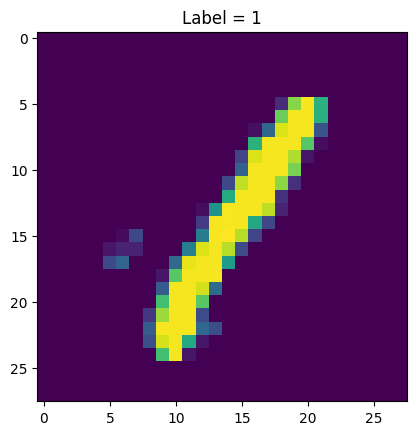

In [4]:
# TEST

train_dataset, train_dataloader = load_mnist(batch_size=1, train=True)
ex_image, ex_label = train_dataset[random.randint(0,1000)]
plot_image_and_label(ex_image.reshape(28,28), ex_label)

## Section 2: Torch Modules (10 min)

Pytorch is a library that will allow you to define neural network objects (nn.modules) for your entire network of whatever operations you want, select a loss function, and then ...
 automatically calculate the gradient for you

Pytorch is built off of modules (called ```nn.Module```) which consist of 2 parts: The initialization (defined in ```__init__()``` -- note that this the python convention for initalizing classes) and the forward pass (defined aptly as ```forward()```)

What is magical about Pytorch is that you simply define these two things and then the gradient can be found *auotmatically*. So all that grueling code you wrote last time... totally unnecessary now. It still helps you in the long run though -- I promise.

Documentation for a pytorch module can be found [here](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)

In this section we will create a Mulit-Layer perceptron using

In [5]:
class MyMLP(nn.Module):

    '''
    in init you should initialize your model
    in forward you just need to use the layers initialized in init to get the output of your model

    The input 'sizes' is a list of the layer sizes, with sizes[0] being the input size and sizes[-1] being the output size.
    This model will only use linear layers so you must flatten the input appropriately.
    '''

    def __init__(self, sizes=[784, 20, 10]):
        super(MyMLP, self).__init__()

        # TODO initalize your model here
        #################################
        self.layer1 = nn.Linear(sizes[0], sizes[1])
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(sizes[1], sizes[2])



        #################################


    def forward(self, x):

        # TODO perform the forward pass of you model
        # use the module you initialized above
        #################################
        x = x.view(x.size(0), -1)
        x = torch.relu(self.layer1(x))
        out = self.layer2(x)

        #################################

        return out

In [6]:
#no

## Section 3 : Classification (15 min)
In this section we will implement the Cross-Entropy loss and create a training loop to minimize it using our model.

In [7]:
# TODO your implementation of cross entropy -- i.e. A softmax over input scores and then negative log loss on those probabilities and the true probs.
def cross_entropy(scores, true_probs):
    if scores.dim() == 1:
        scores = scores.unsqueeze(0)
    probs = torch.softmax(scores, dim=1)
    sloss = -torch.sum(true_probs * torch.log(probs + 1e-9), dim=1)
    loss = torch.mean(sloss) # Must return a torch Tensor (i.e. you must be able to differentiate through this)
    return loss

In [8]:
# Compare to torch's implementation

x = torch.tensor([9.0 , 5.0, 4.0, 2.0, 1.0])
y = torch.tensor([0.9, 0.01, 0.09, 0.0, 0.0])

ce_loss = torch.nn.CrossEntropyLoss()
print("Pytroch CE:",ce_loss(x,y))
print("Your CE:", cross_entropy(x,y))


Pytroch CE: tensor(0.5160)
Your CE: tensor(0.5160)


#### Training loop
Now you are finally ready to train your neural network! Complete your ```training()``` function. You can iterate over your data for 30 epochs (epochs = number of times you iterate over all your data) to begin with. In order to write your training loop, the following general structure can be followed:
```
# initialize loss_function and optimizer
model = MyMLP()
for iteration in range(epochs):
    for input, output in train_dl:
        reset optimizer gradients
        my_output = model(input)
        loss = loss_function(my_output, loss)
        step over gradients using optimizer
```


[Hint for reseting the optimizer](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html#torch.optim.Optimizer.zero_grad)

[Hint for stepping with the optimizer](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.step.html#torch.optim.Optimizer.step) (You'll have to use .backward() to get the gradient)

In [18]:
def training(lr, epochs, train_data, model, device='cpu'):
    '''
    Returns a trained model, a list of training losses (per epoch),
    and a list of training accuracies (per epoch).
    '''
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    train_accuracies = []

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for images, labels in train_data:
            images = images.to(device)
            labels = labels.to(device)

            opt.zero_grad()
            outputs = model(images)
            loss = cross_entropy(outputs, labels)
            loss.backward()
            opt.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total_samples += outputs.size(0)
            correct_predictions += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_data)
        epoch_acc = correct_predictions / total_samples

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(f"Epoch {epoch+1}/{epochs}  |  Loss: {epoch_loss:.4f}  |  Accuracy: {epoch_acc:.4f}")

    return model, train_losses, train_accuracies

def eval(model, loader, device):
    '''Evaluate without updating weights. Returns (avg_loss, accuracy_percent).'''
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = cross_entropy(outputs, labels)
            batch_size = outputs.size(0)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += batch_size
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

In [ ]:
# Plot your training curve here -- both loss and accuracy should be reported.
import matplotlib.pyplot as plt

epochs = 30

train_dataset, train_loader = load_mnist(batch_size=32, train=True)
trained_model, train_losses, train_accuracies = training(lr = 0.001, epochs = epochs, train_data = train_dataloader, model = MyMLP())
test_losses, test_accuracies = eval(model = trained_model, loader = train_loader)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epoch = range(1, epochs + 1)

ax1.plot(epoch, train_losses, 'b-o', label='Train')
ax1.plot(epoch, test_losses, 'b-o', label='Test')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Cross-entropy loss'); ax1.legend()

ax2.plot(epoch, train_accuracies, 'b-o', label='Train')
ax2.plot(epoch, test_accuracies, 'b-o', label='Test')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend()
ax2.set_ylim(90, 100)

plt.tight_layout()
plt.show()

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Epoch 1/30  |  Loss: 102.5559  |  Accuracy: 0.1013
Epoch 2/30  |  Loss: 102.5556  |  Accuracy: 0.1033
Epoch 3/30  |  Loss: 102.5556  |  Accuracy: 0.0982
Epoch 4/30  |  Loss: 102.5556  |  Accuracy: 0.0996
Epoch 5/30  |  Loss: 102.5556  |  Accuracy: 0.0989
Epoch 6/30  |  Loss: 102.5556  |  Accuracy: 0.0985


## Section 4 : Open-Ended (30 min per)
Here I give you 4 open ended challenges. In the live session you may choose one to attempt in the 30 minutes. Afterward I expect that you will complete at least 2 of them. </br> (Additional completed challenges will be noted and will award towards a letter of recommendation.)
</br></br>
You may use any technique that is available in the given libraries to do each of these.

### Challenge 1 (Compute Restricted): Oh No! You only have 1kb of RAM but you need to be able to read these digits! You must create a model that uses fewer than 1000 parameters but achieves over 80% training accuracy and 50% test accuracy to pass this challenge.

### Challenge 2 (Robustness): Create a model and prove that it is robust to Partial occlution, rotation, and reflection transformations. I do not have a specific number for this one, but it will be up to you to prove through testing or mathematics.

### Challenge 3 (Oops! all inputs): Unsupervised learning (no labels) -- traing a model without any labels such that it can achieve >=90% test accuracy.

### Challenge 4 (Black hat beginner): Using any model which you have trained to >=95% train accuracy create 10 examples which are changed from previously correctly-predicted data but are now misclassified. These inputs should be shown side by side (they should not look different). Whoever is able to do this with the smallest magnitude changes will also get special notice.